importing dataset and exploring the csv


In [6]:
import pandas as pd
from matplotlib import pyplot as plt

In [7]:
data = pd.read_csv("../dataset/Data_Entry_2017_v2020.csv")

In [8]:
data.index

RangeIndex(start=0, stop=112120, step=1)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Sex                  112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
dtypes: float64(2), int64(5), object(4)
memory usage: 9.4+ MB


In [10]:
data.shape

(112120, 11)

In [11]:
data.columns

Index(['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID',
       'Patient Age', 'Patient Sex', 'View Position', 'OriginalImage[Width',
       'Height]', 'OriginalImagePixelSpacing[x', 'y]'],
      dtype='object')

In [12]:
data['Finding Labels'] = data['Finding Labels'].apply(lambda x:x.replace("|",","))

In [13]:
# All 15 possible labels (14 diseases + No Finding)
ALL_LABELS = [
    'Atelectasis','Cardiomegaly','Effusion','Infiltration',
    'Mass','Nodule','Pneumonia','Pneumothorax','Consolidation',
    'Edema','Emphysema','Fibrosis','Pleural_Thickening',
    'Hernia','No Finding'
]

# Create binary columns
for label in ALL_LABELS:
    data[label] = data['Finding Labels'].apply(lambda x: 1 if label in x else 0)

# Check class distribution
counts = data[ALL_LABELS].sum().sort_values(ascending=False)
print(type(counts))

<class 'pandas.core.series.Series'>


checking for the age distribution

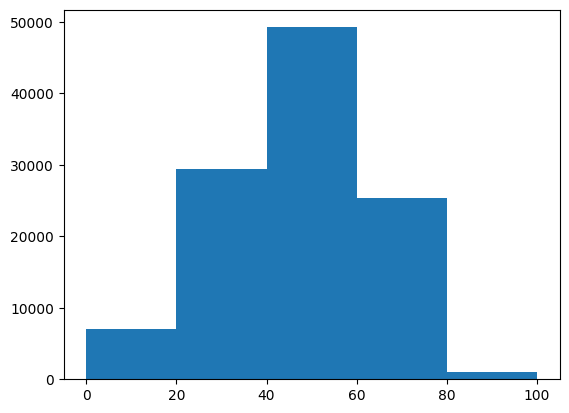

{'whiskers': [<matplotlib.lines.Line2D at 0x1d8f18e10c0>,
 'caps': [<matplotlib.lines.Line2D at 0x1d8f18e16c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1d8f18e0dc0>],
 'medians': [<matplotlib.lines.Line2D at 0x1d8f18e18d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1d8f18e1bd0>],
 'means': []}

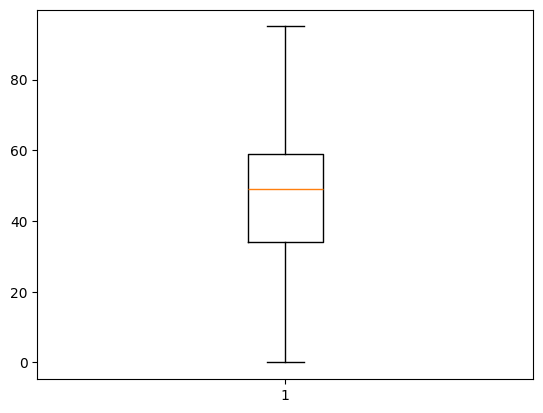

In [14]:
plt.hist(data['Patient Age'], bins=[0,20,40,60,80,100])
plt.show()
plt.boxplot(data['Patient Age'])


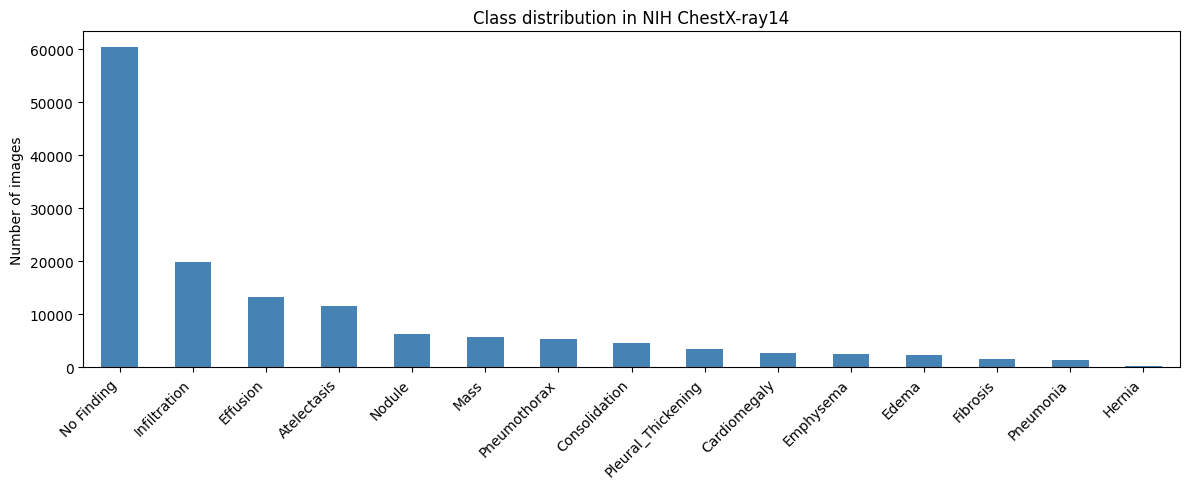

In [15]:
plt.figure(figsize=(12, 5))
counts.plot(kind='bar', color='steelblue')
plt.title('Class distribution in NIH ChestX-ray14')
plt.ylabel('Number of images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

the above plot shows that the data is highly umbalanced

In [16]:
print(counts)

No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64


In [17]:
summ = counts.sum()
for count in counts.index:
    print(count,"-"*50,(counts[count]/summ) * 100)

No Finding -------------------------------------------------- 42.64679907020779
Infiltration -------------------------------------------------- 14.05568861852378
Effusion -------------------------------------------------- 9.408847156573898
Atelectasis -------------------------------------------------- 8.166769113376713
Nodule -------------------------------------------------- 4.47303531938645
Mass -------------------------------------------------- 4.085150879275384
Pneumothorax -------------------------------------------------- 3.746016942566255
Consolidation -------------------------------------------------- 3.297371005461469
Pleural_Thickening -------------------------------------------------- 2.3916007828341708
Cardiomegaly -------------------------------------------------- 1.9613246006344631
Emphysema -------------------------------------------------- 1.777627051583685
Edema -------------------------------------------------- 1.627136367169009
Fibrosis ------------------------------

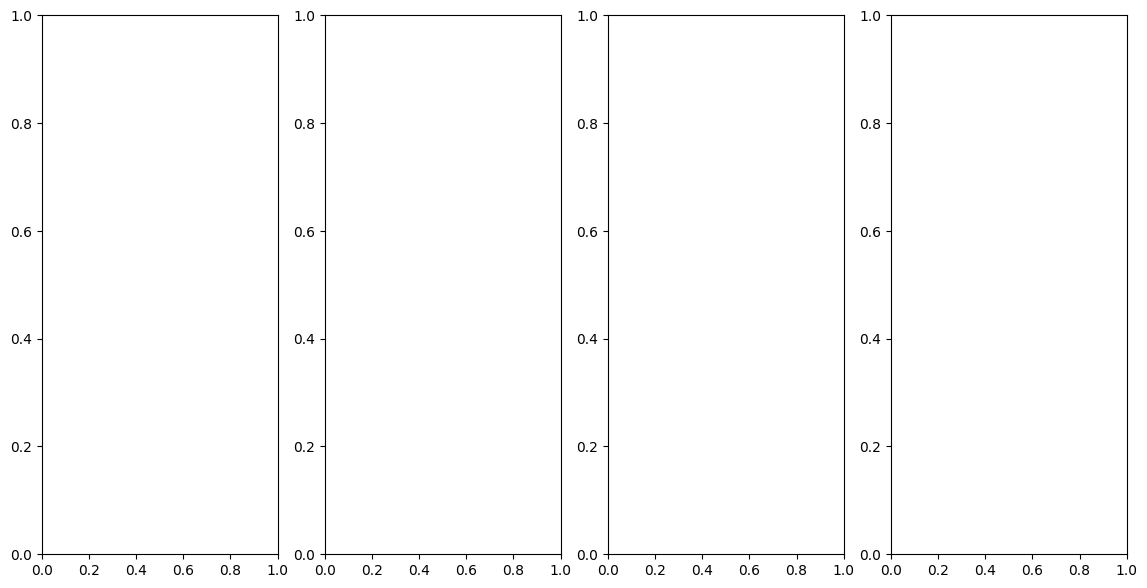

In [18]:
from PIL import Image
import os
from pathlib import Path

img_dir = Path('../dataset/images_01/images/')  # folder where you unzipped the images

# Show a grid of sample X-rays
fig, axes = plt.subplots(1, 4, figsize=(14, 7))
sample = [f.name for f in img_dir.iterdir() if f.is_file()]

for ax, row in zip(axes.flatten(), sample):
    img_path = os.path.join(img_dir, row)
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(row[:25], fontsize=8)
    ax.axis('off')

# plt.tight_layout()
plt.show()

In [19]:
# Load official splits — no patient leakage between sets
with open('../dataset/train_val_list.txt') as f:
    train_files = set(f.read().splitlines())

with open('../dataset/test_list.txt') as f:
    test_files = set(f.read().splitlines())

data['split'] = data['Image Index'].apply(
    lambda x: 'train' if x in train_files else 'test'
)

print(data['split'].value_counts())
# train: ~86k  |  test: ~25k

print("train",data['split'].value_counts().loc['train']*100/data['split'].value_counts().sum())
print("test",data['split'].value_counts().loc['test']*100/data['split'].value_counts().sum())

split
train    86524
test     25596
Name: count, dtype: int64
train 77.17088833392793
test 22.829111666072066


In [20]:
data['split'].value_counts()

split
train    86524
test     25596
Name: count, dtype: int64

In [1]:
import os
import shutil
from pathlib import Path
import tarfile

for file in [Path(f"../dataset/images_{x:02d}.tar.gz") for x in range(6,7)]:
    
    try:
        with tarfile.open(file, "r:gz") as tar:
            # Modern Python versions support the 'data' filter for safer extraction
            tar.extractall(path=f"../dataset/{file.stem}/", filter='data')
        print("extraction finished for ", file,"\nmoving to images folder")

        for i in os.listdir(f"../dataset/{file.stem}/"+"images"):
            shutil.move(f"../dataset/{file.stem}"+"/images/"+i,"../dataset/images/"+i)
        print("moving done for ",file)
    except:
        print("issue with",file)
        continue


extraction finished for  ..\dataset\images_06.tar.gz 
moving to images folder
moving done for  ..\dataset\images_06.tar.gz
